# Run 3 Baselines on 6 Cities

Runs Persistence, Linear Regression, and LSTM next-hour temperature baselines for
each of the 6 metro areas in `all_cities_hourly_weather.csv`.

**LSTM upgrades in this version (vs first pass):**
1. Extra time features (`hour_sin/cos`, `doy_sin/cos`) so the LSTM doesn't have to re-discover the diurnal cycle.
2. Residual target: predict `next_temp - last_temp_in_window`, so the model focuses on what persistence gets wrong.
3. Early stopping with best-checkpoint restoration (patience = 5 val epochs).

Persistence and Linear Regression are unchanged -- they still use the original 5 features -- so comparisons are apples-to-apples.

**GPU is strongly recommended** (Runtime -> Change runtime type -> GPU).

In [ ]:
# ============================================================
# CELL 1: Imports
# ============================================================
import copy
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
# ============================================================
# CELL 2: Config
# ============================================================
SEED        = 42
LOOKBACK    = 24
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.20
BATCH_SIZE  = 64
EPOCHS      = 50      # upper bound; early stopping usually triggers first
PATIENCE    = 5       # stop if val loss hasn't improved for this many epochs
LR          = 1e-3
HIDDEN_SIZE = 64
NUM_LAYERS  = 1

# Features used by Persistence + Linear Regression (unchanged from v1)
FEATURES      = ["temperature", "humidity", "wind_u", "wind_v", "precipitation"]
# Extra features seen ONLY by the LSTM (encode time-of-day and time-of-year)
TIME_FEATURES = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]
LSTM_FEATURES = FEATURES + TIME_FEATURES

TARGET_IDX = 0  # temperature is feature 0 in both lists

CSV_PATH = "all_cities_hourly_weather.csv"

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [ ]:
# ============================================================
# CELL 3: Load data + derive wind_u / wind_v + time features
# ============================================================
df_all = pd.read_csv(CSV_PATH)
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
df_all = df_all.sort_values(["city", "timestamp"]).reset_index(drop=True)

# Wind vectors from meteostat wind_speed (km/h) + wind_dir (deg, meteorological)
theta = np.deg2rad(df_all["wind_dir"])
speed = df_all["wind_speed"]
df_all["wind_u"] = -speed * np.sin(theta)
df_all["wind_v"] = -speed * np.cos(theta)

# Cyclical time-of-day and time-of-year encodings for the LSTM
hour = df_all["timestamp"].dt.hour
doy  = df_all["timestamp"].dt.dayofyear
df_all["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
df_all["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
df_all["doy_sin"]  = np.sin(2 * np.pi * doy  / 365.25)
df_all["doy_cos"]  = np.cos(2 * np.pi * doy  / 365.25)

df_all = df_all.dropna(subset=FEATURES).reset_index(drop=True)

print(df_all[["city", "timestamp", *LSTM_FEATURES]].head())
print("\nRows per city:")
print(df_all.groupby("city").size())

     city           timestamp  temperature  humidity     wind_u     wind_v  \
0  Boston 2020-01-01 00:00:00          3.7      79.0  11.258330  -6.500000   
1  Boston 2020-01-01 01:00:00          3.7      79.0  12.802501   2.257426   
2  Boston 2020-01-01 02:00:00          3.7      79.0  15.934867   9.200000   
3  Boston 2020-01-01 03:00:00          4.2      76.0  16.347809   2.882560   
4  Boston 2020-01-01 04:00:00          3.7      79.0  17.082791  14.334164   

   precipitation  hour_sin  hour_cos   doy_sin   doy_cos  
0            0.0  0.000000  1.000000  0.017202  0.999852  
1            0.0  0.258819  0.965926  0.017202  0.999852  
2            0.0  0.500000  0.866025  0.017202  0.999852  
3            0.0  0.707107  0.707107  0.017202  0.999852  
4            0.0  0.866025  0.500000  0.017202  0.999852  

Rows per city:
city
Boston     52608
Chicago    52608
Denver     52608
Orlando    52608
Phoenix    52608
Seattle    52608
dtype: int64


In [ ]:
# ============================================================
# CELL 4: Shared preprocessing + sequence builder
# ============================================================
def preprocess_city(city_df, feature_cols):
    data = city_df[feature_cols].values.astype(np.float32)
    ts   = city_df["timestamp"].values

    split_idx = int(len(data) * TRAIN_RATIO)
    train_data, test_data = data[:split_idx], data[split_idx:]
    train_ts,   test_ts   = ts[:split_idx],   ts[split_idx:]

    mean = train_data.mean(axis=0)
    std  = train_data.std(axis=0)
    std[std == 0] = 1.0

    train_scaled = (train_data - mean) / std
    test_scaled  = (test_data  - mean) / std

    return train_scaled, test_scaled, train_ts, test_ts, mean, std


def create_sequences(data_scaled, ts, lookback=LOOKBACK):
    X, y, y_ts = [], [], []
    for i in range(lookback, len(data_scaled)):
        X.append(data_scaled[i - lookback:i])
        y.append(data_scaled[i][TARGET_IDX])
        y_ts.append(ts[i])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
    return X, y, np.asarray(y_ts)

In [ ]:
# ============================================================
# CELL 5: Model 1 - Persistence
# ============================================================
def run_persistence(X_test, y_test, mean, std):
    preds = X_test[:, -1, TARGET_IDX].reshape(-1, 1)
    preds_unscaled  = preds  * std[TARGET_IDX] + mean[TARGET_IDX]
    y_true_unscaled = y_test * std[TARGET_IDX] + mean[TARGET_IDX]

    mae  = mean_absolute_error(y_true_unscaled, preds_unscaled)
    rmse = math.sqrt(mean_squared_error(y_true_unscaled, preds_unscaled))
    return {"mae": mae, "rmse": rmse, "preds": preds_unscaled, "truth": y_true_unscaled}

In [ ]:
# ============================================================
# CELL 6: Model 2 - Linear Regression on the flattened window
# ============================================================
def run_linreg(X_train, y_train, X_test, y_test, mean, std):
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat  = X_test.reshape(X_test.shape[0], -1)

    model = LinearRegression()
    model.fit(X_train_flat, y_train.ravel())
    preds = model.predict(X_test_flat).reshape(-1, 1)

    preds_unscaled  = preds  * std[TARGET_IDX] + mean[TARGET_IDX]
    y_true_unscaled = y_test * std[TARGET_IDX] + mean[TARGET_IDX]

    mae  = mean_absolute_error(y_true_unscaled, preds_unscaled)
    rmse = math.sqrt(mean_squared_error(y_true_unscaled, preds_unscaled))
    return {"mae": mae, "rmse": rmse, "preds": preds_unscaled, "truth": y_true_unscaled}

In [ ]:
# ============================================================
# CELL 7: Model 3 - LSTM v2
#   - 9 input features (5 weather + 4 time encodings)
#   - residual target: y - last_temp_in_window
#   - early stopping on val loss, restore best weights
# ============================================================
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):         return len(self.X)
    def __getitem__(self, i):  return self.X[i], self.y[i]


class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_size, 1)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])


def run_lstm(X_train_full, y_train_full, X_test, y_test, mean, std, verbose=False):
    set_seed()

    # --- Residual target (everything still in scaled space) ---
    last_temp_train_full = X_train_full[:, -1, TARGET_IDX].reshape(-1, 1)
    last_temp_test       = X_test[:, -1, TARGET_IDX].reshape(-1, 1)
    y_train_full_res     = (y_train_full - last_temp_train_full).astype(np.float32)

    # --- Time-ordered train/val split (val is the END of train) ---
    val_start = int(len(X_train_full) * (1 - VAL_RATIO))
    X_train, y_train_res = X_train_full[:val_start], y_train_full_res[:val_start]
    X_val,   y_val_res   = X_train_full[val_start:], y_train_full_res[val_start:]

    train_loader = DataLoader(WeatherDataset(X_train, y_train_res), batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = DataLoader(WeatherDataset(X_val,   y_val_res),   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(WeatherDataset(X_test,  y_test),      batch_size=BATCH_SIZE, shuffle=False)  # y_test unused inside the test loop

    model     = LSTMRegressor(input_size=X_train.shape[2]).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state    = None
    best_epoch    = 0
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        # --- train ---
        model.train()
        total = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total += loss.item() * Xb.size(0)
        train_losses.append(total / len(train_loader.dataset))

        # --- validate ---
        model.eval()
        total = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                total += criterion(model(Xb), yb).item() * Xb.size(0)
        val_loss = total / len(val_loader.dataset)
        val_losses.append(val_loss)

        # --- early stopping ---
        if val_loss < best_val_loss - 1e-6:
            best_val_loss     = val_loss
            best_state        = copy.deepcopy(model.state_dict())
            best_epoch        = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose:
            flag = "*" if epoch == best_epoch else " "
            print(f"  epoch {epoch:02d}{flag}  train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}")

        if epochs_no_improve >= PATIENCE:
            break

    # Restore the best weights before testing
    if best_state is not None:
        model.load_state_dict(best_state)

    # --- predict on test set ---
    model.eval()
    preds_chunks = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            preds_chunks.append(model(Xb.to(DEVICE)).cpu().numpy())
    preds_residual = np.vstack(preds_chunks)

    # Undo the residual parameterization, then unscale to degrees C
    preds_scaled    = preds_residual + last_temp_test
    preds_unscaled  = preds_scaled * std[TARGET_IDX] + mean[TARGET_IDX]
    y_true_unscaled = y_test       * std[TARGET_IDX] + mean[TARGET_IDX]

    mae  = mean_absolute_error(y_true_unscaled, preds_unscaled)
    rmse = math.sqrt(mean_squared_error(y_true_unscaled, preds_unscaled))

    return {
        "mae": mae, "rmse": rmse,
        "preds": preds_unscaled, "truth": y_true_unscaled,
        "train_losses": train_losses, "val_losses": val_losses,
        "best_epoch": best_epoch, "epochs_run": len(train_losses),
    }

In [ ]:
# ============================================================
# CELL 8: Main loop - run all 3 models for every city
# Persistence + LinReg use the 5 base features.
# LSTM uses the 9-feature extended set (base + time features).
# ============================================================
results_rows  = []
city_outputs  = {}

for city, city_df in df_all.groupby("city", sort=False):
    print(f"\n========== {city}  (rows={len(city_df):,}) ==========")

    # --- Baseline features (5) for persistence + linreg ---
    tr_s, te_s, tr_ts, te_ts, mean, std = preprocess_city(city_df, FEATURES)
    X_train, y_train, _        = create_sequences(tr_s, tr_ts)
    X_test,  y_test,  y_test_ts = create_sequences(te_s, te_ts)

    pers = run_persistence(X_test, y_test, mean, std)
    print(f"Persistence       MAE={pers['mae']:.4f}  RMSE={pers['rmse']:.4f}")

    lr = run_linreg(X_train, y_train, X_test, y_test, mean, std)
    print(f"LinearRegression  MAE={lr['mae']:.4f}  RMSE={lr['rmse']:.4f}")

    # --- Extended features (9) for LSTM ---
    tr_sL, te_sL, tr_tsL, te_tsL, meanL, stdL = preprocess_city(city_df, LSTM_FEATURES)
    X_trainL, y_trainL, _ = create_sequences(tr_sL, tr_tsL)
    X_testL,  y_testL, _  = create_sequences(te_sL, te_tsL)

    lstm = run_lstm(X_trainL, y_trainL, X_testL, y_testL, meanL, stdL, verbose=False)
    print(f"LSTM              MAE={lstm['mae']:.4f}  RMSE={lstm['rmse']:.4f}   "
          f"(best epoch {lstm['best_epoch']} / {lstm['epochs_run']} run)")

    for name, res in [("Persistence", pers), ("LinearRegression", lr), ("LSTM", lstm)]:
        results_rows.append({"city": city, "model": name, "MAE": res["mae"], "RMSE": res["rmse"]})

    city_outputs[city] = {
        "y_test_ts": y_test_ts,
        "truth":     pers["truth"],
        "pers":      pers["preds"],
        "lr":        lr["preds"],
        "lstm":      lstm["preds"],
        "lstm_train_losses": lstm["train_losses"],
        "lstm_val_losses":   lstm["val_losses"],
        "lstm_best_epoch":   lstm["best_epoch"],
    }


========== Boston  (rows=52,608) ==========
Persistence       MAE=0.6699  RMSE=0.9929
LinearRegression  MAE=0.5946  RMSE=0.8485
LSTM              MAE=0.5512  RMSE=0.7861   (best epoch 13 / 18 run)

========== Chicago  (rows=52,608) ==========
Persistence       MAE=0.6241  RMSE=0.9082
LinearRegression  MAE=0.4704  RMSE=0.7151
LSTM              MAE=0.4878  RMSE=0.7079   (best epoch 16 / 21 run)

========== Denver  (rows=52,608) ==========
Persistence       MAE=1.0172  RMSE=1.3187
LinearRegression  MAE=0.7020  RMSE=0.9711
LSTM              MAE=0.6906  RMSE=0.9607   (best epoch 11 / 16 run)

========== Orlando  (rows=52,608) ==========
Persistence       MAE=0.8717  RMSE=1.2513
LinearRegression  MAE=0.6572  RMSE=0.9354
LSTM              MAE=0.5965  RMSE=0.8835   (best epoch 10 / 15 run)

========== Phoenix  (rows=52,608) ==========
Persistence       MAE=1.0671  RMSE=1.3964
LinearRegression  MAE=0.6976  RMSE=0.9241
LSTM              MAE=0.6473  RMSE=0.8693   (best epoch 6 / 11 run)

=======

In [ ]:
# ============================================================
# CELL 9: Results summary
# ============================================================
results_df = pd.DataFrame(results_rows)

print("\n--- Long format ---")
print(results_df.round(4).to_string(index=False))

print("\n--- Wide format (MAE) ---")
mae_pivot = results_df.pivot(index="city", columns="model", values="MAE").round(4)
print(mae_pivot)

print("\n--- Wide format (RMSE) ---")
rmse_pivot = results_df.pivot(index="city", columns="model", values="RMSE").round(4)
print(rmse_pivot)

# % improvement over persistence, for quick scanning
pers_mae = mae_pivot["Persistence"]
improvement = pd.DataFrame({
    "LinReg_%gain_vs_Pers": (1 - mae_pivot["LinearRegression"] / pers_mae) * 100,
    "LSTM_%gain_vs_Pers":   (1 - mae_pivot["LSTM"]             / pers_mae) * 100,
}).round(1)
print("\n--- % MAE reduction vs Persistence ---")
print(improvement)

results_df.to_csv("baseline_results_all_cities.csv", index=False)
print("\nSaved baseline_results_all_cities.csv")


--- Long format ---
   city            model    MAE   RMSE
 Boston      Persistence 0.6699 0.9929
 Boston LinearRegression 0.5946 0.8485
 Boston             LSTM 0.5512 0.7861
Chicago      Persistence 0.6241 0.9082
Chicago LinearRegression 0.4704 0.7151
Chicago             LSTM 0.4878 0.7079
 Denver      Persistence 1.0172 1.3187
 Denver LinearRegression 0.7020 0.9711
 Denver             LSTM 0.6906 0.9607
Orlando      Persistence 0.8717 1.2513
Orlando LinearRegression 0.6572 0.9354
Orlando             LSTM 0.5965 0.8835
Phoenix      Persistence 1.0671 1.3964
Phoenix LinearRegression 0.6976 0.9241
Phoenix             LSTM 0.6473 0.8693
Seattle      Persistence 0.6631 0.9427
Seattle LinearRegression 0.5415 0.7248
Seattle             LSTM 0.5267 0.6919

--- Wide format (MAE) ---
model      LSTM  LinearRegression  Persistence
city                                          
Boston   0.5512            0.5946       0.6699
Chicago  0.4878            0.4704       0.6241
Denver   0.6906        

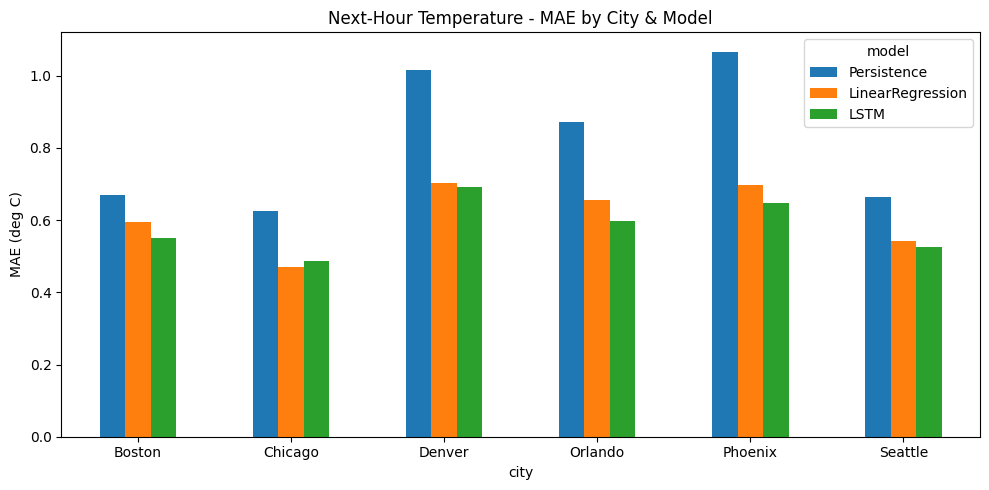

In [ ]:
# ============================================================
# CELL 10: Bar chart - MAE per city per model
# ============================================================
ax = mae_pivot[["Persistence", "LinearRegression", "LSTM"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
ax.set_ylabel("MAE (deg C)")
ax.set_title("Next-Hour Temperature - MAE by City & Model")
plt.tight_layout()
plt.show()

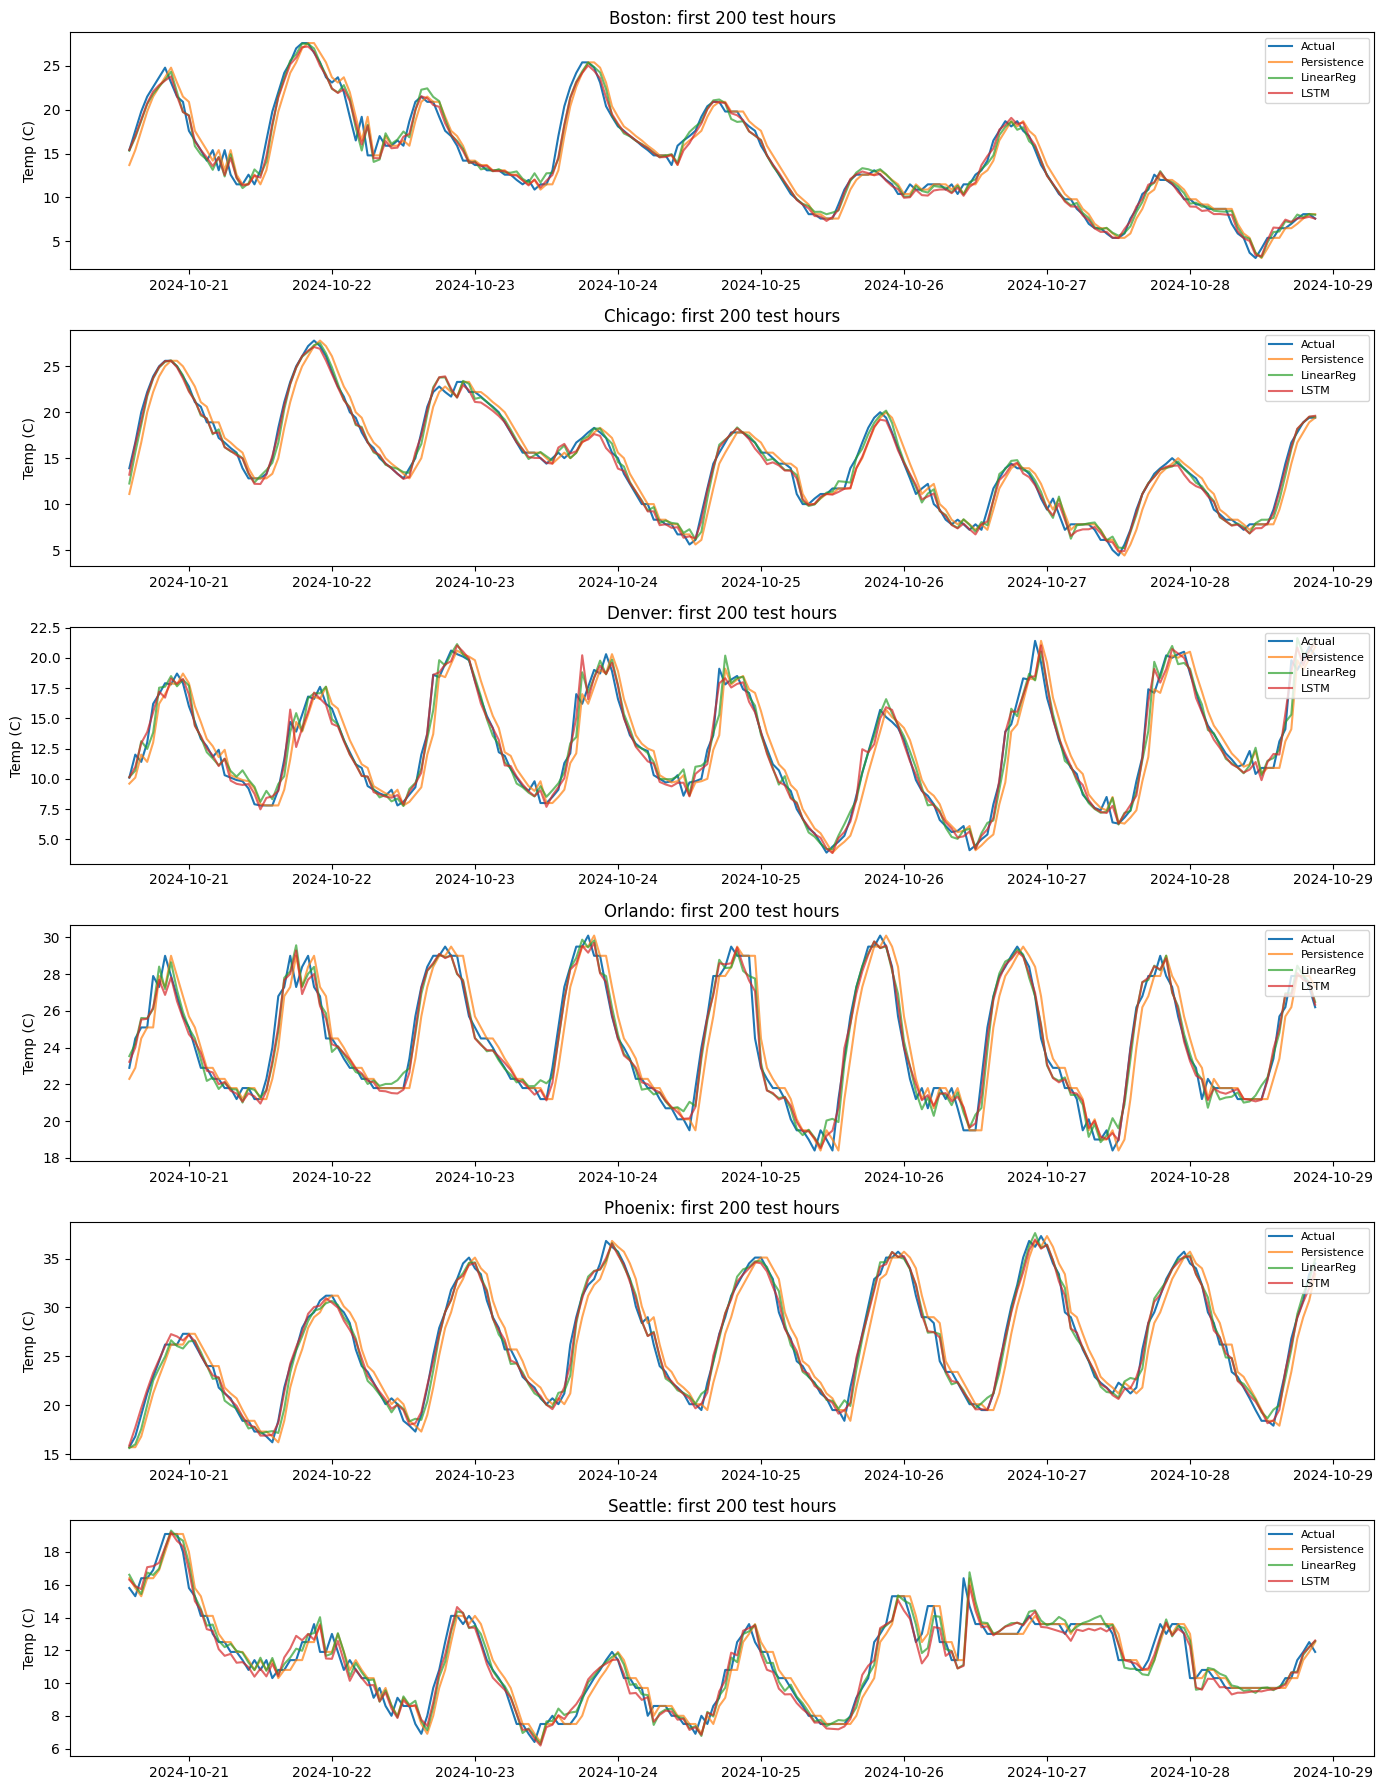

In [ ]:
# ============================================================
# CELL 11: Per-city prediction plots (first 200 test hours)
# ============================================================
cities = list(city_outputs.keys())
fig, axes = plt.subplots(len(cities), 1, figsize=(14, 3 * len(cities)), sharex=False)

for ax, city in zip(axes, cities):
    o = city_outputs[city]
    n = min(200, len(o["truth"]))
    ax.plot(o["y_test_ts"][:n], o["truth"][:n], label="Actual",      linewidth=1.5)
    ax.plot(o["y_test_ts"][:n], o["pers"][:n],  label="Persistence", alpha=0.7)
    ax.plot(o["y_test_ts"][:n], o["lr"][:n],    label="LinearReg",   alpha=0.7)
    ax.plot(o["y_test_ts"][:n], o["lstm"][:n],  label="LSTM",        alpha=0.7)
    ax.set_title(f"{city}: first {n} test hours")
    ax.set_ylabel("Temp (C)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

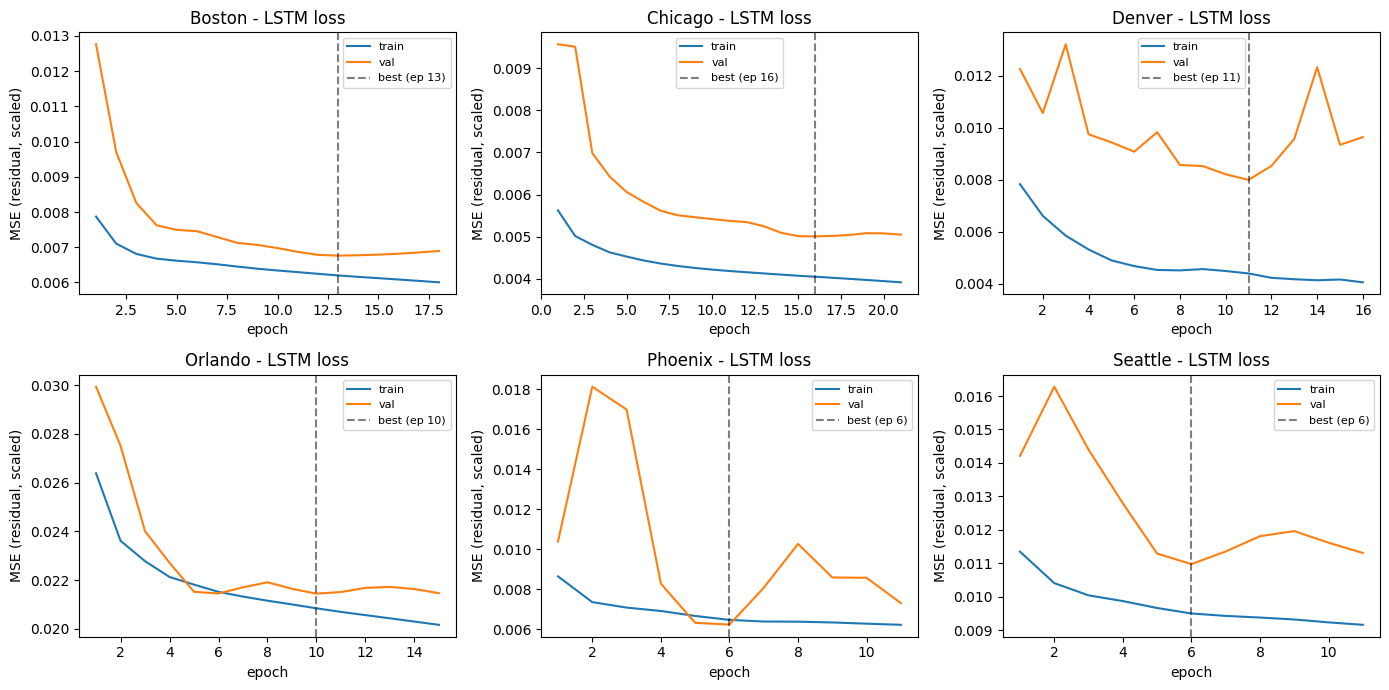

In [ ]:
# ============================================================
# CELL 12: LSTM loss curves + best-epoch marker per city
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=False)
for ax, city in zip(axes.flatten(), cities):
    o = city_outputs[city]
    epochs = range(1, len(o["lstm_train_losses"]) + 1)
    ax.plot(epochs, o["lstm_train_losses"], label="train")
    ax.plot(epochs, o["lstm_val_losses"],   label="val")
    ax.axvline(o["lstm_best_epoch"], color="k", linestyle="--", alpha=0.5,
               label=f"best (ep {o['lstm_best_epoch']})")
    ax.set_title(f"{city} - LSTM loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE (residual, scaled)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 13: (Optional) Download results from Colab
# ============================================================
# from google.colab import files
# files.download("baseline_results_all_cities.csv")